# Board Games Exploratory Data Analysis
**Dataset:** [Board Games Database from BoardGameGeek](https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek)

Basic Info about the dataset
1. Interaction matrix sparsity
2. Ratings per user (cold-start problem)
3. Game popularity & long-tail distribution

In [5]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [6]:
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")
print(f"Path to dataset files: {path}")

games = pd.read_csv(f"{path}/games.csv")
user_ratings = pd.read_csv(f"{path}/user_ratings.csv")
mechanics = pd.read_csv(f"{path}/mechanics.csv")
subcategories = pd.read_csv(f"{path}/subcategories.csv")
artist = pd.read_csv(f"{path}/artists_reduced.csv")
publisher = pd.read_csv(f"{path}/publishers_reduced.csv")

print(f"games: {games.shape}")
print(f"user_ratings: {user_ratings.shape}")
print(f"mechanics: {mechanics.shape}")
print(f"subcategories: {subcategories.shape}")
print(f"artist: {artist.shape}")
print(f"publisher: {publisher.shape}")

100%|██████████| 148M/148M [00:00<00:00, 168MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4
games: (21925, 48)
user_ratings: (18942215, 3)
mechanics: (21925, 158)
subcategories: (21925, 11)
artist: (21925, 1681)
publisher: (21925, 1866)


## Initial EDA for Games

In [7]:
games.head()

,BGGId,Name,Description,YearPublished,GameWeight,AvgRating,BayesAvgRating,StdDev,MinPlayers,MaxPlayers,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
0,1,Die Macher,die macher game seven sequential political rac...,1986,4.3206,7.61428,7.10363,1.57979,3,5,...,21926,21926,0,1,0,0,0,0,0,0
1,2,Dragonmaster,dragonmaster tricktaking card game base old ga...,1981,1.9630,6.64537,5.78447,1.45440,3,4,...,21926,21926,0,1,0,0,0,0,0,0
2,3,Samurai,samurai set medieval japan player compete gain...,1998,2.4859,7.45601,7.23994,1.18227,2,4,...,21926,21926,0,1,0,0,0,0,0,0
3,4,Tal der Könige,triangular box luxurious large block tal der k...,1992,2.6667,6.60006,5.67954,1.23129,2,4,...,21926,21926,0,0,0,0,0,0,0,0
4,5,Acquire,acquire player strategically invest business t...,1964,2.5031,7.33861,7.14189,1.33583,2,6,...,21926,21926,0,1,0,0,0,0,0,0


We can see theres an extra coloumn BGGId that is essentially the board game's index offset by one. We should remove this later since its value has no significance.

In [8]:
games.dtypes

,0
BGGId,int64
Name,object
Description,object
YearPublished,int64
GameWeight,float64
AvgRating,float64
BayesAvgRating,float64
StdDev,float64
MinPlayers,int64
MaxPlayers,int64


In [9]:
games.isnull().sum()

,0
BGGId,0
Name,0
Description,1
YearPublished,0
GameWeight,0
AvgRating,0
BayesAvgRating,0
StdDev,0
MinPlayers,0
MaxPlayers,0


We can see that several columns have many missing values like `Family`, `ComAgeRec`, and `LanguageEase` being in the thousands. Two other columns with significantly less missing values would be `Description` and `ImagePath`. With **21925** rows of data in the dataset, a column like Family missing **15262** is quite significant making up around 70% of the dataset. This means we need to investigate the significance of these columns, and either drop them, or augment the data to fill in the values since removing 70% of the rows would effect the performance of the model.

In [10]:
games.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'AvgRating', 'BayesAvgRating', 'StdDev', 'MinPlayers', 'MaxPlayers',
       'ComAgeRec', 'LanguageEase', 'BestPlayers', 'GoodPlayers', 'NumOwned',
       'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime',
       'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumComments',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Family', 'Kickstarted', 'ImagePath',
       'Rank:boardgame', 'Rank:strategygames', 'Rank:abstracts',
       'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
       'Rank:partygames', 'Rank:childrensgames', 'Cat:Thematic',
       'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract',
       'Cat:Party', 'Cat:Childrens'],
      dtype='object')

Now investigating the columns in question and more.

In [11]:
games[['Family', 'ComAgeRec', 'LanguageEase', 'Description', "ImagePath"]]

,Family,ComAgeRec,LanguageEase,Description,ImagePath
0,Classic Line (Valley Games),14.366667,1.395833,die macher game seven sequential political rac...,https://cf.geekdo-images.com/rpwCZAjYLD940NWwP...
1,NaN,NaN,27.000000,dragonmaster tricktaking card game base old ga...,https://cf.geekdo-images.com/oQYhaJx5Lg3KcGis2...
2,Euro Classics (Reiner Knizia),9.307692,1.000000,samurai set medieval japan player compete gain...,https://cf.geekdo-images.com/o9-sNXmFS_TLAb7Zl...
3,NaN,13.000000,256.000000,triangular box luxurious large block tal der k...,https://cf.geekdo-images.com/nYiYhUlatT2DpyXaJ...
4,3M Bookshelf,11.410256,21.152941,acquire player strategically invest business t...,https://cf.geekdo-images.com/3C--kJRhi6kTPHsr9...
...,...,...,...,...,...
21920,NaN,12.000000,NaN,oil tanker fire rescue team send deal damage...,https://cf.geekdo-images.com/Uzx3n6dd0LGC2sGyS...
21921,NaN,16.000000,98.000000,new square edition include nippon expansion up...,https://cf.geekdo-images.com/eG4UBkwA9SNNEFUkE...
21922,NaN,12.000000,155.000000,million year people force play timehonored gam...,https://cf.geekdo-images.com/TRCPgnDKCu8civrbB...
21923,NaN,NaN,31.000000,splitter group number score point mdash s s md...,https://cf.geekdo-images.com/6ILh7aNVHosY-m5gG...


Because the actual value contained inside `ImagePath` is not significant, we will just remove that column since each boardgame will have its own unique link. However, we could potentially revist this column and take advantage of a CNN to predict if the cover iamge of a game relates to whether a game receives higher reviews similar to Netflix. The `Description` column is similar in that all rows will have a unique entry and will be dropped, but an llm could potentially be integrated to parse the description and create relavent tags. `Names` is irrelavent and will be dropped completely.

In [12]:
# Count unique entries in the family column
family_counts = games['Family'].value_counts()
print(family_counts)
print("")
print(family_counts.describe())


Family
18xx                                                  103
Monopoly (Official)                                    73
Trivial Pursuit                                        67
Werewolf / Mafi                                        58
Wallet Games (Button Shy)                              45
                                                     ... 
Hunt a Kill                                             1
Warhammer 40,000 (Ninth Edition)                        1
Personal Spac                                           1
Unsolved Case Fil                                       1
Triangle System (Predrag Lazovic / Dragan Lazovic)      1
Name: count, Length: 1456, dtype: int64

count    1456.000000
mean        4.576236
std         6.584452
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       103.000000
Name: count, dtype: float64


Because thare are about 1456 categories, with the top category `18xx` labeling **103** of the **21925** board games in the dataset, it wouldn't be practical to agument the other **70%** of the column if the current labels don't do a good job of representing the games. Therefore we will choose to drop this column as well.

array([[<Axes: title={'center': 'Rank:boardgame'}>,
        <Axes: title={'center': 'Rank:strategygames'}>,
        <Axes: title={'center': 'Rank:abstracts'}>],
       [<Axes: title={'center': 'Rank:familygames'}>,
        <Axes: title={'center': 'Rank:thematic'}>,
        <Axes: title={'center': 'Rank:cgs'}>],
       [<Axes: title={'center': 'Rank:wargames'}>,
        <Axes: title={'center': 'Rank:partygames'}>,
        <Axes: title={'center': 'Rank:childrensgames'}>]], dtype=object)

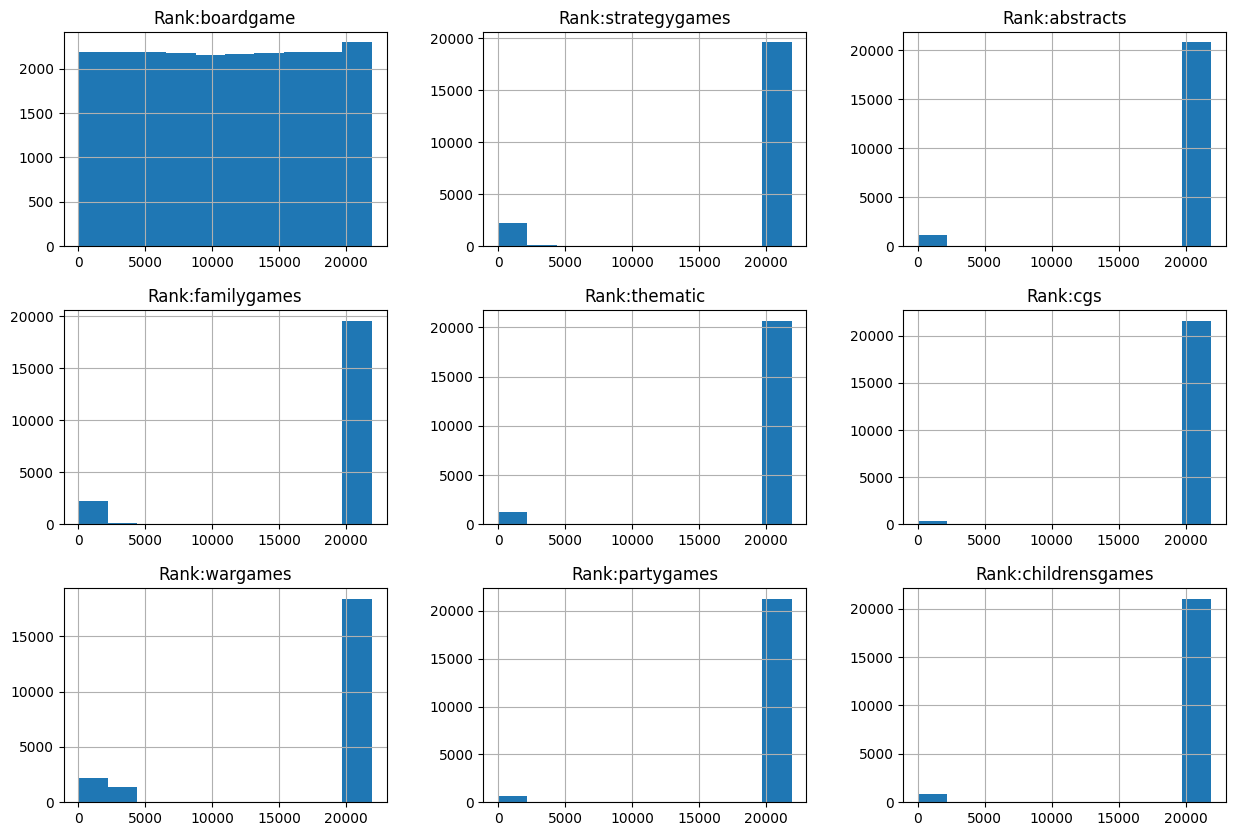

In [13]:
games[['Rank:boardgame', 'Rank:strategygames', 'Rank:abstracts',
       'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
       'Rank:partygames', 'Rank:childrensgames']].hist(figsize=(15, 10))

array([[<Axes: title={'center': 'Cat:Thematic'}>,
        <Axes: title={'center': 'Cat:Strategy'}>,
        <Axes: title={'center': 'Cat:War'}>],
       [<Axes: title={'center': 'Cat:Family'}>,
        <Axes: title={'center': 'Cat:CGS'}>,
        <Axes: title={'center': 'Cat:Abstract'}>],
       [<Axes: title={'center': 'Cat:Party'}>,
        <Axes: title={'center': 'Cat:Childrens'}>, <Axes: >]],
      dtype=object)

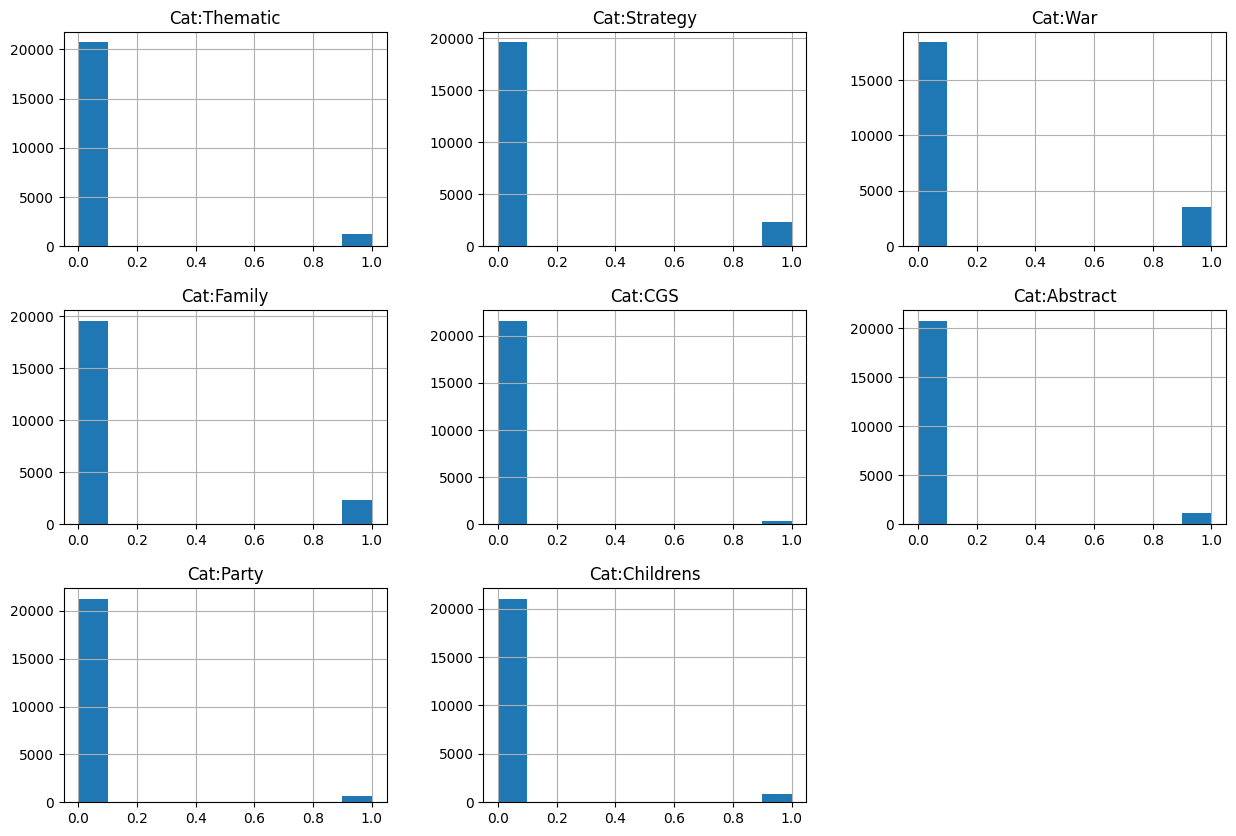

In [14]:
games[['Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family',
       'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']].hist(figsize=(15, 10))

All the categories and ranks for the games are essentially bool values that tell whether the game is apart of that category or not with the exception of `Rank:boardgame`. I assume that the tags seperated a one hot encoding of the catergories and ranks into seperate columns. In our case we can simple normalize the data to 1s and 0s for better model training.

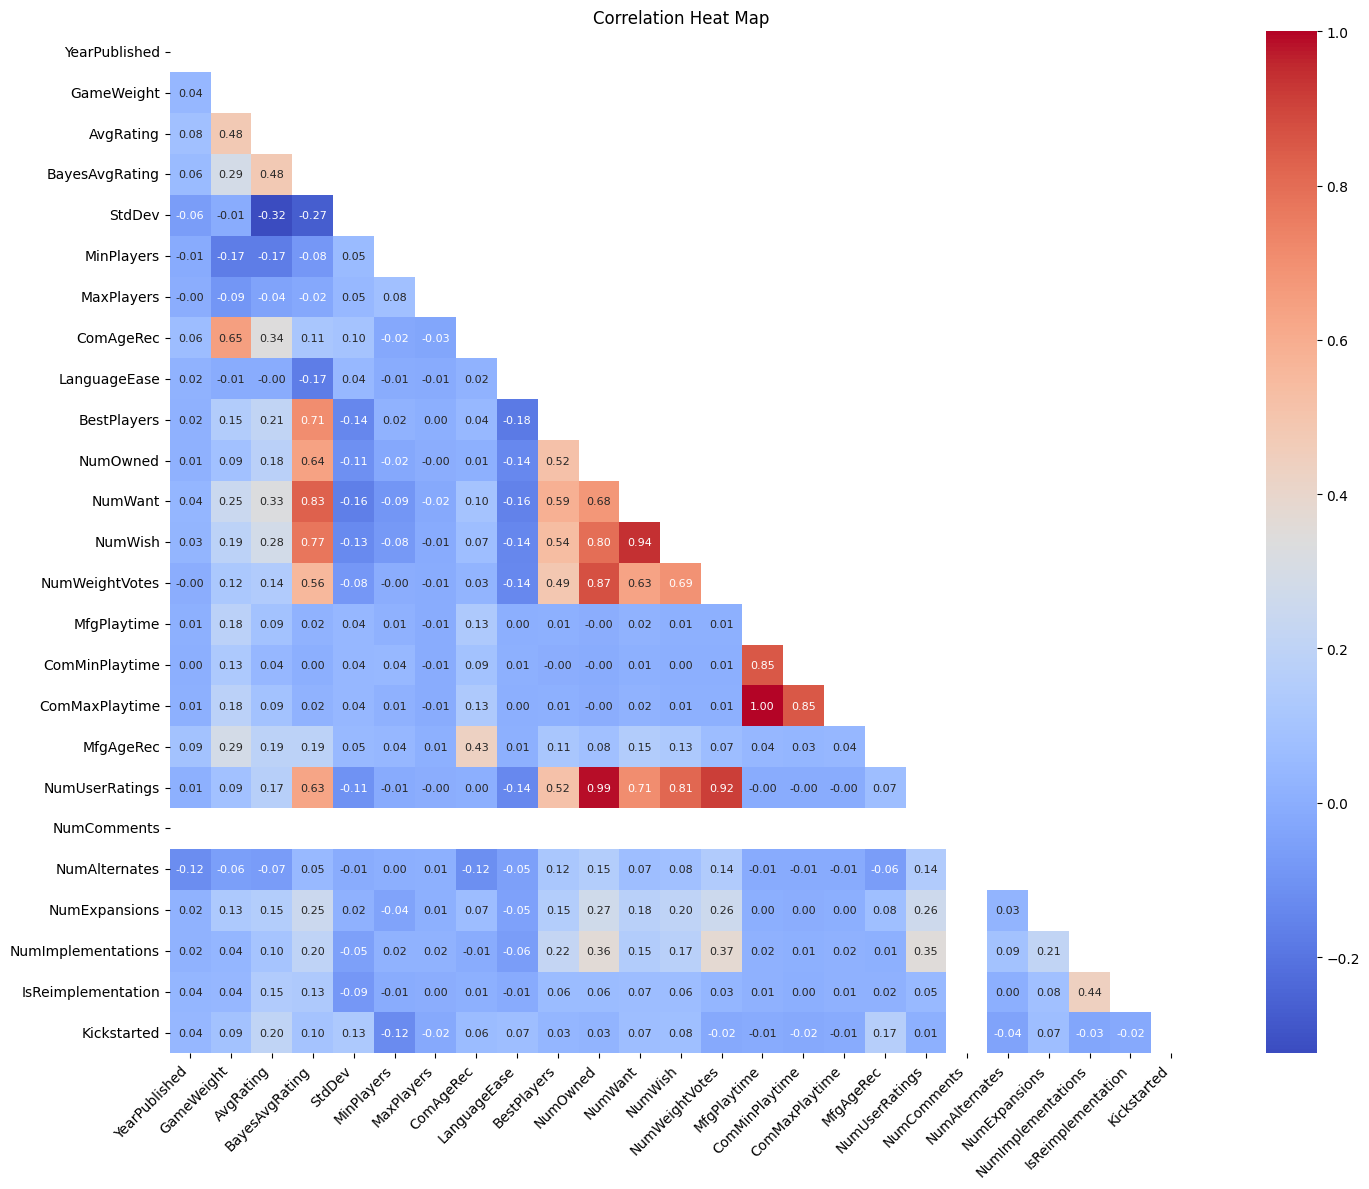

In [24]:
numerical_data = games[['YearPublished', 'GameWeight',
       'AvgRating', 'BayesAvgRating', 'StdDev', 'MinPlayers', 'MaxPlayers',
       'ComAgeRec', 'LanguageEase', 'BestPlayers', 'NumOwned',
       'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime',
       'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumComments',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted']]

plt.figure(figsize=(16, 12))

correlationMap = numerical_data.corr(method='pearson')

# Create a mask for the upper triangle
mask = np.triu(correlationMap)

sns.heatmap(
    correlationMap,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="coolwarm",
    mask=mask # Apply the mask here
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Heat Map")
plt.tight_layout()
plt.show()

Now exploring the rest of the datasets

In [16]:
user_ratings.head()

,BGGId,Rating,Username
0,213788,8.0,Tonydorrf
1,213788,8.0,tachyon14k
2,213788,8.0,Ungotter
3,213788,8.0,brainlocki3
4,213788,8.0,PPMP


In [20]:
mechanics.head()

,BGGId,Alliances,Area Majority / Influence,Auction/Bidding,Dice Rolling,Hand Management,Simultaneous Action Selection,Trick-taking,Hexagon Grid,Once-Per-Game Abilities,...,Contracts,Passed Action Token,King of the Hill,Action Retrieval,Force Commitment,Rondel,Automatic Resource Growth,Legacy Game,Dexterity,Physical
0,1,1,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,1,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,4,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
subcategories.head()

,BGGId,Exploration,Miniatures,Territory Building,Card Game,Educational,Puzzle,Collectible Components,Word Game,Print & Play,Electronic
0,1,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,1,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0
4,5,0,0,1,0,0,0,0,0,0,0


In [22]:
artist.head()

,Harald Lieske,Franz Vohwinkel,Peter Whitley,Scott Okumura,(Uncredited),Doris Matthäus,Alan R. Moon,Alexander Jung,Andrea Boekhoff,Björn Pertoft,...,Nathan Meunier,Andrey Gordeev,Zbigniew Umgelter,Jeppe Norsker,Daniel Profiri,Aleksander Zawada,Simon Douchy,Felix Wermke,BGGId,Low-Exp Artist
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,4,1
4,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,0


In [23]:
publisher.head()

,Hans im Glück,Moskito Spiele,Portal Games,Spielworxx,Stronghold Games,"Valley Games, Inc.",YOKA Games,sternenschimmermeer,E.S. Lowe,Milton Bradley,...,Cacahuete Games,BlackSands Games,Norsker Games,Perro Loko Games,Funko Games,Origame,Deep Print Games,Hidden Industries GmbH,BGGId,Low-Exp Publisher
0,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,2,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,4,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,1


In [25]:
publisher.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Columns: 1866 entries, Hans im Glück to Low-Exp Publisher
dtypes: int64(1866)
memory usage: 312.1 MB


It seems like the rest of the metadata datasets are already one hot encoded which is convient for us as we may use them as is other than the BGGId col that we may remove. Now we will explore how the features impact the ratings

In [30]:
ratings = user_ratings.groupby(by=["BGGId"], dropna=False)["Rating"].mean()
ratings = pd.DataFrame(ratings.reset_index())
ratings = ratings.drop(["BGGId"], axis=1)
ratings

,Rating
0,7.672014
1,6.642697
2,7.484350
3,6.599476
4,7.439818
...,...
21920,7.326190
21921,7.790845
21922,6.820896
21923,6.465152


In [31]:
cats = pd.DataFrame({"cat": ['Exploration', 'Miniatures', 'Territory Building', 'Card Game','Educational', 'Puzzle', 'Collectible Components', 'Word Game','Print & Play', 'Electronic']})
cats = pd.concat([cats, ratings], axis=1)
cats.head()

,cat,Rating
0,Exploration,7.672014
1,Miniatures,6.642697
2,Territory Building,7.484350
3,Card Game,6.599476
4,Educational,7.439818


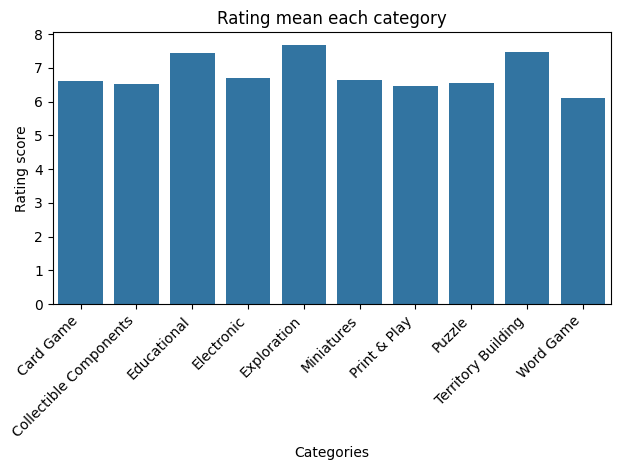

In [35]:
series = cats.groupby(['cat']).Rating.mean()
sns.barplot(x = series.index, y = series.values)
plt.title('Rating mean each category')
plt.xlabel('Categories')
plt.ylabel('Rating score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Text(0, 0.5, 'Rating score')

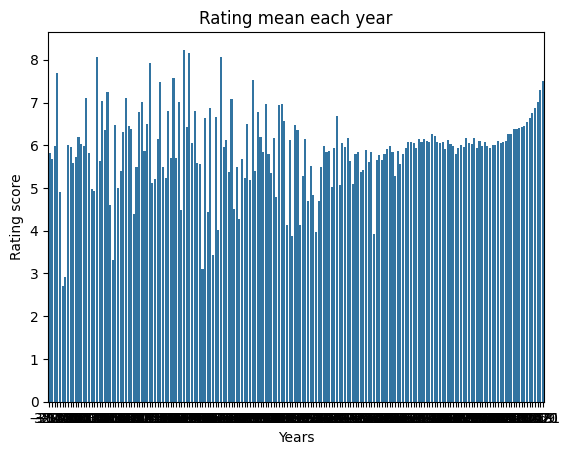

In [37]:
years = pd.concat([games,ratings],axis=1)
series = years.groupby(['YearPublished']).Rating.mean()
sns.barplot(x = series.index, y = series.values)
plt.title('Rating mean each year')
plt.xlabel('Years')
plt.ylabel('Rating score')

We can see that it is very spurratic in the beginning but average ratings began to rise through time

## 1. Sparsity

In [17]:
n_users = user_ratings['Username'].nunique()
n_games = user_ratings['BGGId'].nunique()
n_ratings = len(user_ratings)
n_possible = n_users * n_games
sparsity = 1 - n_ratings / n_possible
summary = pd.DataFrame({
    "Metric": ["Unique users", "Unique games", "Total ratings", "Possible cells", "Sparsity"],
    "Value": [f"{n_users:,}", f"{n_games:,}", f"{n_ratings:,}", f"{n_possible:,}", f"{sparsity*100:.2f}%"]
})
summary.set_index("Metric")

,Value
Metric,
Unique users,"411,374"
Unique games,"21,925"
Total ratings,"18,942,215"
Possible cells,"9,019,374,950"
Sparsity,99.79%


## 2. Ratings Per User (Cold-Start Signal)

Ratings per user — summary stats
count    411374.000000
mean         46.046060
std         108.431797
min           1.000000
25%           2.000000
50%          12.000000
75%          44.000000
max        6493.000000

Threshold              % of users
<= 5                        36.7%
<= 10                       47.2%
<= 20                       59.9%
<= 50                       77.6%
<= 100                      88.4%


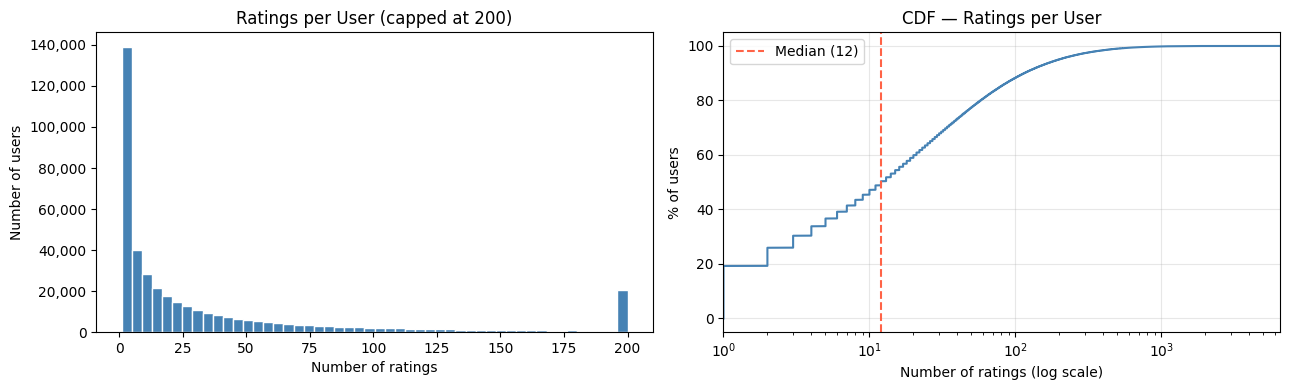

In [18]:
ratings_per_user = user_ratings.groupby('Username').size()

print("Ratings per user — summary stats")
print(ratings_per_user.describe().rename("ratings/user").to_string())
print()

thresholds = [5, 10, 20, 50, 100]
print(f"{'Threshold':<20} {'% of users':>12}")
for t in thresholds:
    pct = (ratings_per_user <= t).mean() * 100
    print(f"<= {t:<17} {pct:>11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_user.clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Ratings per User (capped at 200)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

sorted_vals = np.sort(ratings_per_user.values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf * 100, color='steelblue', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_xlim(1, sorted_vals.max())
axes[1].set_xlabel("Number of ratings (log scale)")
axes[1].set_ylabel("% of users")
axes[1].set_title("CDF — Ratings per User")
axes[1].axvline(12, color='tomato', linestyle='--', label='Median (12)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Game popularity & long-tail distribution

Top 10 most-rated games:


,Ratings,% of all
Game,,
Pandemic,107760,0.569
Carcassonne,107601,0.568
Catan,106725,0.563
7 Wonders,89014,0.470
Dominion,80901,0.427
Ticket to Ride,75352,0.398
Codenames,73188,0.386
Terraforming Mars,72753,0.384
7 Wonders Duel,68063,0.359



Top  1% of games ( 219 titles) → 33.8% of all ratings
Top 10% of games (2192 titles) → 76.7% of all ratings

Games with  <50 ratings : 19.9%
Games with <100 ratings : 43.9%

Catan: 106,725 ratings  (0.563% of all)
Pandemic: 107,760 ratings  (0.569% of all)


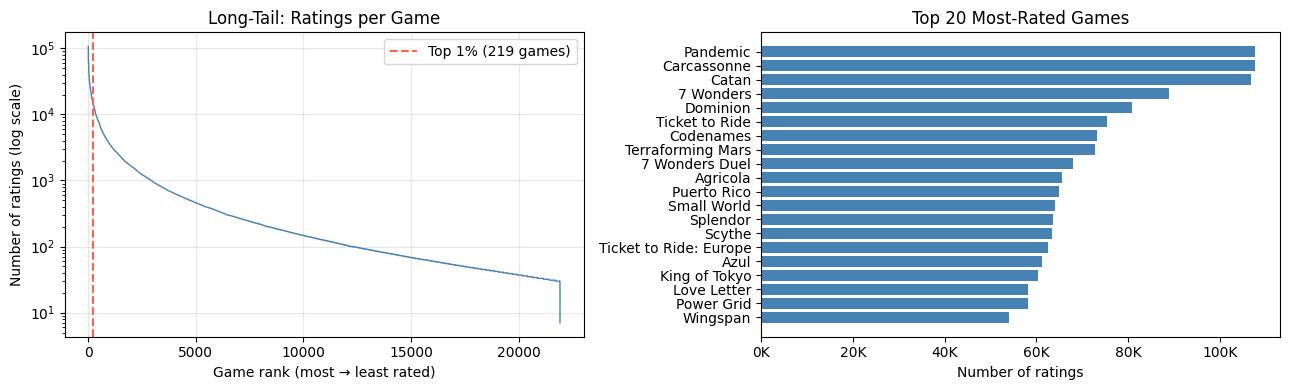

In [19]:
ratings_per_game = user_ratings.groupby('BGGId').size().sort_values(ascending=False)
total_ratings = ratings_per_game.sum()
game_names = games.set_index('BGGId')['Name']

top10 = ratings_per_game.head(10).reset_index()
top10.columns = ['BGGId', 'Ratings']
top10['Game'] = top10['BGGId'].map(game_names)
top10['% of all'] = (top10['Ratings'] / total_ratings * 100).round(3)
print("Top 10 most-rated games:")
display(top10[['Game', 'Ratings', '% of all']].set_index('Game'))

top_1pct = int(len(ratings_per_game) * 0.01)
top_10pct = int(len(ratings_per_game) * 0.10)
print(f"\nTop  1% of games ({top_1pct:>4} titles) → {ratings_per_game.head(top_1pct).sum()/total_ratings*100:.1f}% of all ratings")
print(f"Top 10% of games ({top_10pct:>4} titles) → {ratings_per_game.head(top_10pct).sum()/total_ratings*100:.1f}% of all ratings")
print(f"\nGames with  <50 ratings : {(ratings_per_game <  50).mean()*100:.1f}%")
print(f"Games with <100 ratings : {(ratings_per_game < 100).mean()*100:.1f}%\n")

for target in ['Catan', 'Pandemic']:
    bid = games[games['Name'] == target]['BGGId'].values[0]
    cnt = ratings_per_game.get(bid, 0)
    print(f"{target}: {cnt:,} ratings  ({cnt/total_ratings*100:.3f}% of all)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(ratings_per_game) + 1), ratings_per_game.values, color='steelblue', linewidth=1)
axes[0].set_yscale('log')
axes[0].set_xlabel("Game rank (most → least rated)")
axes[0].set_ylabel("Number of ratings (log scale)")
axes[0].set_title("Long-Tail: Ratings per Game")
axes[0].axvline(top_1pct, color='tomato', linestyle='--', label=f'Top 1% ({top_1pct} games)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top20_names = [game_names.get(i, f"ID {i}") for i in ratings_per_game.head(20).index]
top20_vals  = ratings_per_game.head(20).values
axes[1].barh(top20_names[::-1], top20_vals[::-1], color='steelblue')
axes[1].set_xlabel("Number of ratings")
axes[1].set_title("Top 20 Most-Rated Games")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

plt.tight_layout()
plt.show()